In [1]:
# Imports

import ray
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from src.parsers import HMParser, CotevParser
from src.resources import Generator, Load, Storage, Aggregator, Vehicle
from src.algorithms.rl import EnergyCommunityEntropyPriorityV1

from ray.rllib.algorithms.ppo import PPOConfig

import warnings
warnings.filterwarnings('ignore')

2025-10-24 13:20:15,708	WARNING deprecation.py:50 -- DeprecationWarning: `DirectStepOptimizer` has been deprecated. This will raise an error in the future!
2025-10-24 13:20:16,020	WARNING deprecation.py:50 -- DeprecationWarning: `build_tf_policy` has been deprecated. This will raise an error in the future!
2025-10-24 13:20:16,023	WARNING deprecation.py:50 -- DeprecationWarning: `build_policy_class` has been deprecated. This will raise an error in the future!


In [2]:
# Model global information
SEASON = 'summer'  # 'winter', 'spring', 'summer', 'autumn'
SEASON_START = 0
SEASON_END = 0

# General data
N_HOUSES = 20
N_STEPS = 24 * 366 * 4  # 14496  # 6576  # 24 * 366
# 1 year - 2020 (leap year), 4 because we are using 15 minutes intervals

In [3]:
# EC data for mostly cost values
data_ec = HMParser(file_path='../../../data/EC_V4.xlsx', ec_id=1)
data_ec.parse()

# EV data from the EV4EU simulator
data_ev = CotevParser(population_path=
                      '../../../data/simulation_20evs_1year_15t/population_366.csv',
                      driving_history_path=
                      '../../../data/simulation_20evs_1year_15t/ev_driving_history_366.csv',
                      assigned_segments_path=
                      '../../../data/simulation_20evs_1year_15t/assigned_segments_366.csv',
                      parse_date_start='2020',
                      parse_date_end='2020')
data_ev.parse()

In [4]:
# Create the generator and load lists to add on to
generators = []
loads = []
used_idx = []

temp_costs_df = pd.DataFrame({'cost_parameter_b': data_ec.generator['cost_parameter_b'][0, 0],
                              'cost_nde': data_ec.generator['cost_nde'][0],
                              'cost_cut': data_ec.load['cost_cut'][0],
                              'cost_reduce': data_ec.load['cost_reduce'][0],
                              'cost_ens': data_ec.load['cost_ens'][0],
                              'discharge_price': np.array(data_ec.storage['discharge_price'][2]),
                              'charge_price': np.array(data_ec.storage['charge_price'][0]),
                              'import_contracted_p_max': 200.0,
                              'export_contracted_p_max': 200.0,
                              'buy_price': data_ec.peers['buy_price'][0],
                              'sell_price': data_ec.peers['sell_price'][0]},  #data_ec.peers['sell_price'][0]},
                             index=pd.date_range(start='2020-01-01', freq='H', periods=24))
# Resample to 15T and forward fill the values
temp_costs_df = temp_costs_df.resample('15T').ffill()
print('Initial costs DataFrame:\n{}'.format(temp_costs_df))

# Now fill the remaining 3 timestamps
temp_costs_df = temp_costs_df.reindex(pd.date_range(start='2020-01-01', freq='15T', periods=96), method='ffill')

Initial costs DataFrame:
                     cost_parameter_b cost_nde cost_cut cost_reduce cost_ens  \
2020-01-01 00:00:00              0.08      4.5      0.6         0.5      4.5   
2020-01-01 00:15:00              0.08      4.5      0.6         0.5      4.5   
2020-01-01 00:30:00              0.08      4.5      0.6         0.5      4.5   
2020-01-01 00:45:00              0.08      4.5      0.6         0.5      4.5   
2020-01-01 01:00:00              0.08      4.5      0.6         0.5      4.5   
...                               ...      ...      ...         ...      ...   
2020-01-01 22:00:00              0.08      4.5      0.6         0.5      4.5   
2020-01-01 22:15:00              0.08      4.5      0.6         0.5      4.5   
2020-01-01 22:30:00              0.08      4.5      0.6         0.5      4.5   
2020-01-01 22:45:00              0.08      4.5      0.6         0.5      4.5   
2020-01-01 23:00:00              0.08      4.5      0.6         0.5      4.5   

              

In [5]:
# Seasonal splits

IS_TRAINING = True

aux_date_range = pd.date_range(start='2020-01-01', freq='15T', periods=N_STEPS)
winter_start = 0
winter_end = aux_date_range.get_loc(aux_date_range[aux_date_range.month == 2].max())
spring_start = aux_date_range.get_loc(aux_date_range[aux_date_range.month == 3].min())
spring_end = aux_date_range.get_loc(aux_date_range[aux_date_range.month == 5].max())
summer_start = aux_date_range.get_loc(aux_date_range[aux_date_range.month == 6].min())
summer_end = aux_date_range.get_loc(aux_date_range[aux_date_range.month == 8].max())
autumn_start = aux_date_range.get_loc(aux_date_range[aux_date_range.month == 9].min())
autumn_end = aux_date_range.get_loc(aux_date_range[aux_date_range.month == 11].max())

if IS_TRAINING:
    if SEASON == 'winter':
        N_STEPS = winter_end - winter_start - 1344
        SEASON_START = winter_start
        SEASON_END = winter_end - 1344
    elif SEASON == 'spring':
        N_STEPS = spring_end - spring_start - 1344
        SEASON_START = spring_start
        SEASON_END = spring_end - 1344
    elif SEASON == 'summer':
        N_STEPS = summer_end - summer_start - 1344
        SEASON_START = summer_start
        SEASON_END = summer_end - 1344
    elif SEASON == 'autumn':
        N_STEPS = autumn_end - autumn_start - 1344
        SEASON_START = autumn_start
        SEASON_END = autumn_end - 1344
else:
    if SEASON == 'winter':
        N_STEPS = 1344
        SEASON_START = winter_end - 1344
        SEASON_END = winter_end
    elif SEASON == 'spring':
        N_STEPS = 1344
        SEASON_START = spring_end - 1344
        SEASON_END = spring_end
    elif SEASON == 'summer':
        N_STEPS = 1344
        SEASON_START = summer_end - 1344
        SEASON_END = summer_end
    elif SEASON == 'autumn':
        N_STEPS = 1344
        SEASON_START = autumn_end - 1344
        SEASON_END = autumn_end

In [6]:
for i in range(1, 2):
    temp_data = pd.read_csv('../../../data/housedata/W/H{}_W.csv'.format(i))

    # Fill the generator and load missing data with zeros
    temp_data = temp_data.fillna(0)

    # Resample to 1H intervals
    temp_data['date'] = pd.to_datetime(temp_data['date'])
    temp_data = temp_data.set_index('date', drop=True)
    temp_data = temp_data.resample('15T').mean()

    # Convert to kW
    temp_data[' Production(kW)'] = temp_data[' Production(W)'] / 1000
    temp_data[' Consumption(kW)'] = temp_data[' Consumption(W)'] / 1000

    # Check if there are enough data points
    if temp_data.shape[0] < 366 * 96:
        print(f'Not enough data for house {i}, skipping...')
        continue

    # Create the generator
    generators.append(Generator(name='ren_generator_{:02d}'.format(i),
                                value=np.zeros(N_STEPS),
                                lower_bound=np.zeros(N_STEPS),
                                upper_bound=temp_data[' Production(kW)'][SEASON_START:SEASON_END],
                                cost=np.tile(temp_costs_df['cost_parameter_b'], (int(N_STEPS / 95)))[:-1],
                                cost_nde=np.tile(temp_costs_df['cost_nde'], (int(N_STEPS / 95)))[:-1],
                                is_renewable=True))

    # Create the load
    loads.append(Load(name='load_{:02d}'.format(i),
                      value=temp_data[' Consumption(kW)'][SEASON_START:SEASON_END],
                      lower_bound=np.zeros(N_STEPS),
                      upper_bound=temp_data[' Consumption(kW)'][SEASON_START:SEASON_END],
                      cost=np.ones(N_STEPS),
                      cost_cut=np.tile(temp_costs_df['cost_cut'], (int(N_STEPS / 95)))[:-1],
                      cost_reduce=np.tile(temp_costs_df['cost_reduce'], (int(N_STEPS / 95)))[:-1],
                      cost_ens=np.tile(temp_costs_df['cost_ens'], (int(N_STEPS / 95)))[:-1]))

    used_idx.append(i - 1)  # Store the index of the house used

# Create the storages
storages = []
for i in used_idx:
    storages.append(Storage(name='storage_{:02d}'.format(i + 1),
                            value=np.tile(8.0, N_STEPS),
                            lower_bound=np.tile(2.0, N_STEPS),
                            upper_bound=np.tile(10.0, N_STEPS),
                            cost=np.zeros(N_STEPS),
                            cost_discharge=np.tile(temp_costs_df['discharge_price'] * 0.0, (int(N_STEPS / 95)))[:-1],
                            cost_charge=np.tile(temp_costs_df['charge_price'], (int(N_STEPS / 95)))[:-1],
                            capacity_max=10.0,
                            capacity_min=2.0,  # 0.2 * capacity_max
                            initial_charge=8.0,
                            discharge_efficiency=0.95,
                            discharge_max=np.tile(3.3, N_STEPS),
                            charge_efficiency=0.95,
                            charge_max=np.tile(3.3, N_STEPS),
                            capital_cost=np.array([0.05250, 0.10500, 0.01575])))

# EVs are already in the data_ev.resources, but we'll trim the excess data
evs = []
for i in used_idx:
    temp_res = data_ev.resources[i]
    evs.append(Vehicle(name='ev_{:02d}'.format(i + 1),
                       value=temp_res.value[SEASON_START:SEASON_END],
                       lower_bound=temp_res.lower_bound[SEASON_START:SEASON_END],
                       upper_bound=temp_res.upper_bound[SEASON_START:SEASON_END],
                       cost=temp_res.cost[SEASON_START:SEASON_END],
                       cost_discharge=temp_res.cost_discharge[SEASON_START:SEASON_END],
                       cost_charge=temp_res.cost_charge[SEASON_START:SEASON_END],
                       capacity_max=temp_res.capacity_max,
                       initial_charge=temp_res.initial_charge,
                       min_charge=temp_res.min_charge,
                       discharge_efficiency=temp_res.discharge_efficiency,
                       charge_efficiency=temp_res.charge_efficiency,
                       schedule_connected=temp_res.schedule_connected[SEASON_START:SEASON_END],
                       schedule_discharge=temp_res.schedule_discharge[SEASON_START:SEASON_END],
                       schedule_charge=temp_res.schedule_charge[SEASON_START:SEASON_END],
                       schedule_requirement_soc=temp_res.schedule_requirement_soc[SEASON_START:SEASON_END],
                       schedule_arrival_soc=temp_res.schedule_arrival_soc[SEASON_START:SEASON_END]))

# Create the aggregator
aggregator = Aggregator(name='aggregator',
                        value=np.zeros(N_STEPS),
                        lower_bound=np.zeros(N_STEPS),
                        upper_bound=np.tile(temp_costs_df['import_contracted_p_max'], (int(N_STEPS / 95)))[:-1],
                        cost=np.tile(data_ec.peers['buy_price'], (int(N_STEPS / 95)))[:-1],
                        imports=np.zeros(N_STEPS),
                        exports=np.zeros(N_STEPS),
                        import_cost=np.tile(temp_costs_df['buy_price'] * 2, (int(N_STEPS / 95)))[:-1],
                        export_cost=np.tile(temp_costs_df['sell_price'], (int(N_STEPS / 95)))[:-1],
                        import_max=np.tile(temp_costs_df['import_contracted_p_max'], (int(N_STEPS / 95)))[:-1],
                        export_max=np.tile(temp_costs_df['export_contracted_p_max'], (int(N_STEPS / 95)))[:-1])


In [7]:
# Create the environment and check if everything is ok
temp_env = EnergyCommunityEntropyPriorityV1(ren_generators=generators,
                                            generators=[],
                                            loads=loads,
                                            storages=storages,
                                            evs=evs,
                                            aggregator=aggregator,
                                            storage_penalty=1,
                                            ev_penalty=1,
                                            balance_penalty=1,
                                            look_ahead=12,
                                            max_episode_length=N_STEPS,
                                            seed=42)

temp_env.reset()
terminations = truncations = {a: False for a in temp_env.agents}
terminations['__all__'] = False
truncations['__all__'] = False

In [8]:
while not terminations['__all__'] and not truncations['__all__']:

    actions = temp_env.action_space.sample()
    next_obs, rewards, terminations, truncations, infos = temp_env.step(actions)

print('Terminated: {}'.format(terminations['__all__']))

Terminated: True


In [9]:
# Get the policy checkpoint - Adaptive

from ray.tune import register_env
from ray.rllib.algorithms.algorithm import Algorithm

checkpoint_path = '/Users/ecgomes/ray_results/PPO_2025-10-24_11-38-46/PPO_EC_Entropy_V1_9e68e_00000_0_2025-10-24_11-38-46/checkpoint_000009'

ray.shutdown()
ray.init()

IMPORT_PENALTY = 1.0  # 100
EXPORT_PENALTY = 1.0  # 10
STORAGE_ACTION_PENALTY = 50.0  # 100
STORAGE_ACTION_REWARD = 5.0  # 10
EV_ACTION_PENALTY = 1.0  # 1000
EV_ACTION_REWARD = 5.0  # 10
EV_REQUIREMENT_PENALTY = 50.0  # 3000
BALANCE_PENALTY = 5000.0  # 20000

#'/Users/ecgomes/ray_results/PPO_2025-08-12_14-22-08/PPO_EC_Entropy_V1_58f56_00000_0_2025-08-12_14-22-08/checkpoint_000027'

# We need to register the environment
env = EnergyCommunityEntropyPriorityV1(ren_generators=generators,
                                       generators=[],
                                       loads=loads,
                                       storages=storages,
                                       evs=evs,
                                       aggregator=aggregator,
                                       storage_penalty=STORAGE_ACTION_PENALTY,
                                       ev_penalty=EV_REQUIREMENT_PENALTY,
                                       balance_penalty=BALANCE_PENALTY,
                                       look_ahead=12,
                                       max_episode_length=N_STEPS-1,
                                       seed=42,
                                       is_training=True)
register_env("EC_Entropy_V1", lambda config: env)

algo = Algorithm.from_checkpoint(checkpoint_path)

2025-10-24 13:20:52,654	INFO worker.py:1642 -- Started a local Ray instance.
2025-10-24 13:20:53,348	WARNING algorithm_config.py:2578 -- Setting `exploration_config={}` because you set `_enable_rl_module_api=True`. When RLModule API are enabled, exploration_config can not be set. If you want to implement custom exploration behaviour, please modify the `forward_exploration` method of the RLModule at hand. On configs that have a default exploration config, this must be done with `config.exploration_config={}`.
2025-10-24 13:20:53,350	WARNING algorithm_config.py:672 -- Cannot create PPOConfig from given `config_dict`! Property __stdout_file__ not supported.
2025-10-24 13:20:53,355	WARNING algorithm_config.py:2578 -- Setting `exploration_config={}` because you set `_enable_rl_module_api=True`. When RLModule API are enabled, exploration_config can not be set. If you want to implement custom exploration behaviour, please modify the `forward_exploration` method of the RLModule at hand. On con

In [16]:
# Run the learned policies

from copy import deepcopy

PATH = '../benchmark_entropy/'

test_env = EnergyCommunityEntropyPriorityV1(ren_generators=generators,
                                            generators=[],
                                            loads=loads,
                                            storages=storages,
                                            evs=evs,
                                            aggregator=aggregator,
                                            storage_penalty=STORAGE_ACTION_PENALTY,
                                            ev_penalty=EV_REQUIREMENT_PENALTY,
                                            balance_penalty=BALANCE_PENALTY,
                                            look_ahead=12,
                                            max_episode_length=N_STEPS, #24*366,
                                            seed=42,
                                            is_training=False)

init_state = {'aggregator': algo.get_policy('aggregator').get_initial_state()}
state = {'aggregator': algo.get_policy('aggregator').get_initial_state()}

for i in storages:
    init_state[i.name] = algo.get_policy(i.name).get_initial_state()
    state[i.name] = algo.get_policy(i.name).get_initial_state()
    
for i in evs:
    init_state[i.name] = algo.get_policy(i.name).get_initial_state()
    state[i.name] = algo.get_policy(i.name).get_initial_state()

obs, info = test_env.reset()

# Set up the terminations and truncations
terminations = truncations = {a: False for a in test_env.agents}
terminations['__all__'] = False
truncations['__all__'] = False

order_history = [test_env.execution_order]

action_history = {i: [] for i in test_env.agents.keys()}
reward_history = {i: [] for i in test_env.agents.keys()}

while not terminations['__all__'] and not truncations['__all__']:

    current_agent = test_env.execution_order[test_env._current_agent_idx]
    #current_policy = 'storage' if current_agent.startswith('storage') else current_agent
    current_policy = current_agent
    
    #print('current agent: ', current_agent)
    #print('current observations: ', obs[current_agent])

    try:
        action_dict, new_state, extra = algo.compute_single_action(observation=obs[current_agent],
                                                                   policy_id=current_policy,
                                                                   state=state[current_agent],
                                                                   explore=False)
        #print('here')
        #print(f'agent: {current_agent} with action: {action_dict}')
    except (TypeError, ValueError):
        action_dict = algo.compute_single_action(observation=obs[current_agent],
                                                 policy_id=current_policy,
                                                 state=state[current_agent],
                                                 explore=False)
        algo.compute_actions()
        new_state = state[current_agent]
        #print('here')
        #print(f'agent: {current_agent} with action: {action_dict}')


    state[current_agent] = new_state

    # print(action_dict.keys())

    obs, rewards, terminations, truncations, info = test_env.step({current_agent: action_dict})

    if current_agent == 'aggregator' and not terminations['__all__'] and not truncations['__all__']:
        order_history.append(test_env.execution_order)

pd_results = pd.DataFrame({})
# Save the renewable generators
for iter in np.arange(len(test_env.ren_generators)):
    agent_name = test_env.ren_generators[iter].name
    pd_results[agent_name] = test_env.ren_generators[iter].value

# Save the storages
for iter in np.arange(len(test_env.storages)):
    agent_name = test_env.storages[iter].name
    pd_results[agent_name] = test_env.storages[iter].value
    pd_results['{}_charge'.format(agent_name)] = test_env.storages[iter].charge
    pd_results['{}_charge_eff'.format(agent_name)] = test_env.storages[iter].charge * test_env.storages[iter].charge_efficiency
    pd_results['{}_discharge'.format(agent_name)] = test_env.storages[iter].discharge
    pd_results['{}_discharge_eff'.format(agent_name)] = test_env.storages[iter].discharge / test_env.storages[iter].discharge_efficiency

# Save the EVs
for iter in np.arange(len(test_env.evs)):
    agent_name = test_env.evs[iter].name
    pd_results[agent_name] = test_env.evs[iter].value
    pd_results['{}_charge'.format(agent_name)] = test_env.evs[iter].charge
    pd_results['{}_charge_eff'.format(agent_name)] = test_env.evs[iter].charge * test_env.evs[iter].charge_efficiency
    pd_results['{}_discharge'.format(agent_name)] = test_env.evs[iter].discharge
    pd_results['{}_discharge_eff'.format(agent_name)] = test_env.evs[iter].discharge / test_env.evs[iter].discharge_efficiency

pd_results['aggregator_action'] = test_env.aggregator.value
pd_results['imports'] = test_env.aggregator.imports
pd_results['exports'] = test_env.aggregator.exports

pd_results['energy_history'] = test_env.energy_history

pd_results['order_history'] = order_history

if not os.path.exists(PATH):
    os.makedirs(PATH)

# pd_results.to_csv('entropy_summer_seed42.csv')

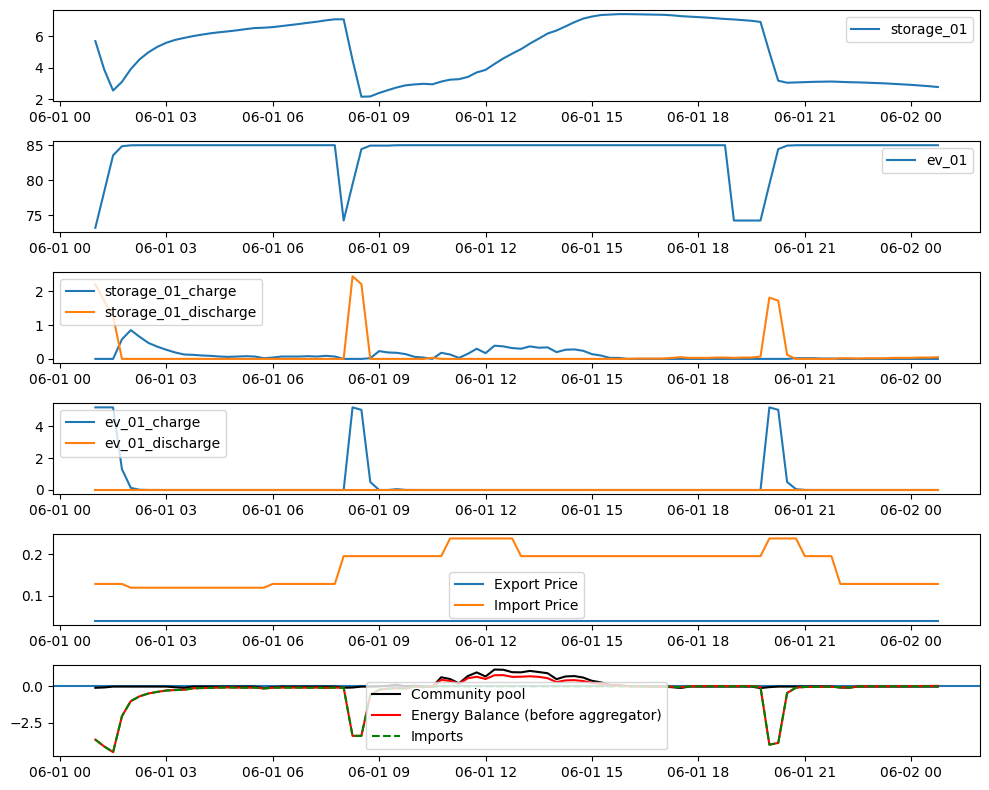

In [19]:
fig, axs = plt.subplots(ncols=1, nrows=6, figsize=(10, 8))

START = 0
END = 1

# Storage and EVs SoC
for i in storages:
    axs[0].plot(pd_results.iloc[96*START:96*END].index, pd_results.iloc[96*START:96*END][i.name].values, label=i.name)
axs[0].legend()

for i in evs:
    axs[1].plot(pd_results.iloc[96*START:96*END].index, pd_results.iloc[96*START:96*END][i.name].values, label=i.name)
axs[1].legend()

# Storage and EV charge and discharge
for i in storages:
    axs[2].plot(pd_results.iloc[96*START:96*END].index, pd_results.iloc[96*START:96*END][f'{i.name}_charge'].values, label=f'{i.name}_charge')
    axs[2].plot(pd_results.iloc[96*START:96*END].index, pd_results.iloc[96*START:96*END][f'{i.name}_discharge'].values, label=f'{i.name}_discharge')
axs[2].legend(loc='upper left')
    
for i in evs:
    axs[3].plot(pd_results.iloc[96*START:96*END].index, pd_results.iloc[96*START:96*END][f'{i.name}_charge_eff'].values, label=f'{i.name}_charge')
    axs[3].plot(pd_results.iloc[96*START:96*END].index, pd_results.iloc[96*START:96*END][f'{i.name}_discharge_eff'].values, label=f'{i.name}_discharge')
axs[3].legend(loc='upper left')

# Pricing
axs[4].plot(pd_results.iloc[96*START:96*END].index, test_env.aggregator.export_cost[96*START:96*END], label='Export Price')
axs[4].plot(pd_results.iloc[96*START:96*END].index, test_env.aggregator.import_cost[96*START:96*END], label='Import Price')
axs[4].legend()

# Production
axs[5].axhline(0.0)
axs[5].plot(pd_results.iloc[96*START:96*END].index, test_env.gen_production[96*START:96*END] - test_env.load_consumption[96*START:96*END], color='black', label='Community pool')
axs[5].plot(pd_results.iloc[96*START:96*END].index, test_env.energy_history[96*START:96*END], color='red', label='Energy Balance (before aggregator)')
axs[5].plot(pd_results.iloc[96*START:96*END].index, -test_env.aggregator.imports[96*START:96*END], color='green', linestyle='--', label='Imports')
axs[5].legend(loc='lower left')

plt.legend()
plt.tight_layout()
plt.show()

In [15]:
pd_results

,ren_generator_01,storage_01,storage_01_charge,storage_01_charge_eff,storage_01_discharge,storage_01_discharge_eff,aggregator_action,imports,exports,energy_history,order_history
date,,,,,,,,,,,
2020-06-01 01:00:00,0.0,7.4947,0.0,0.0,0.48,0.505263,0.0,0.000000,0.381733,0.381733,"[storage_01, aggregator]"
2020-06-01 01:15:00,0.0,7.1368,0.0,0.0,0.34,0.357895,0.0,0.000000,0.265133,0.265133,"[storage_01, aggregator]"
2020-06-01 01:30:00,0.0,6.8947,0.0,0.0,0.23,0.242105,0.0,0.000000,0.213333,0.213333,"[storage_01, aggregator]"
2020-06-01 01:45:00,0.0,6.7473,0.0,0.0,0.14,0.147368,0.0,0.000000,0.124133,0.124133,"[storage_01, aggregator]"
2020-06-01 02:00:00,0.0,6.6526,0.0,0.0,0.09,0.094737,0.0,0.000000,0.073467,0.073467,"[storage_01, aggregator]"
...,...,...,...,...,...,...,...,...,...,...,...
2020-08-17 23:30:00,0.0,5.6409,0.0,0.0,0.10,0.105263,0.0,0.221733,0.000000,-0.221733,"[storage_01, aggregator]"
2020-08-17 23:45:00,0.0,5.4935,0.0,0.0,0.14,0.147368,0.0,0.305533,0.000000,-0.305533,"[storage_01, aggregator]"
2020-08-18 00:00:00,0.0,5.3251,0.0,0.0,0.16,0.168421,0.0,0.333933,0.000000,-0.333933,"[storage_01, aggregator]"


In [15]:
temp_env.storages[0].name

'storage_01'

In [17]:
np.round(np.mean(aggregator.import_cost), 2)

0.17

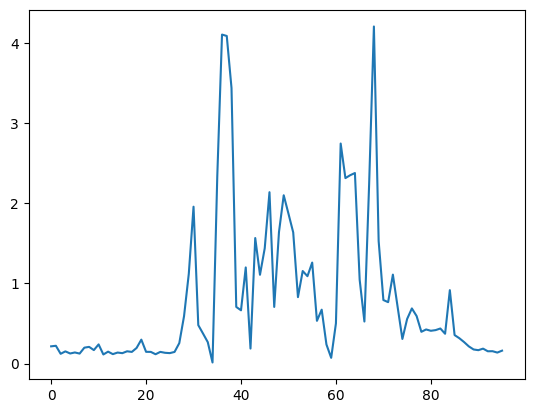

In [14]:
plt.plot([abs(a) for a in test_env.energy_history[96*START:96*END]])

In [18]:
test_env.storages[0].value

array([8.    , 8.    , 8.    , ..., 1.9584, 1.9584, 1.9584])

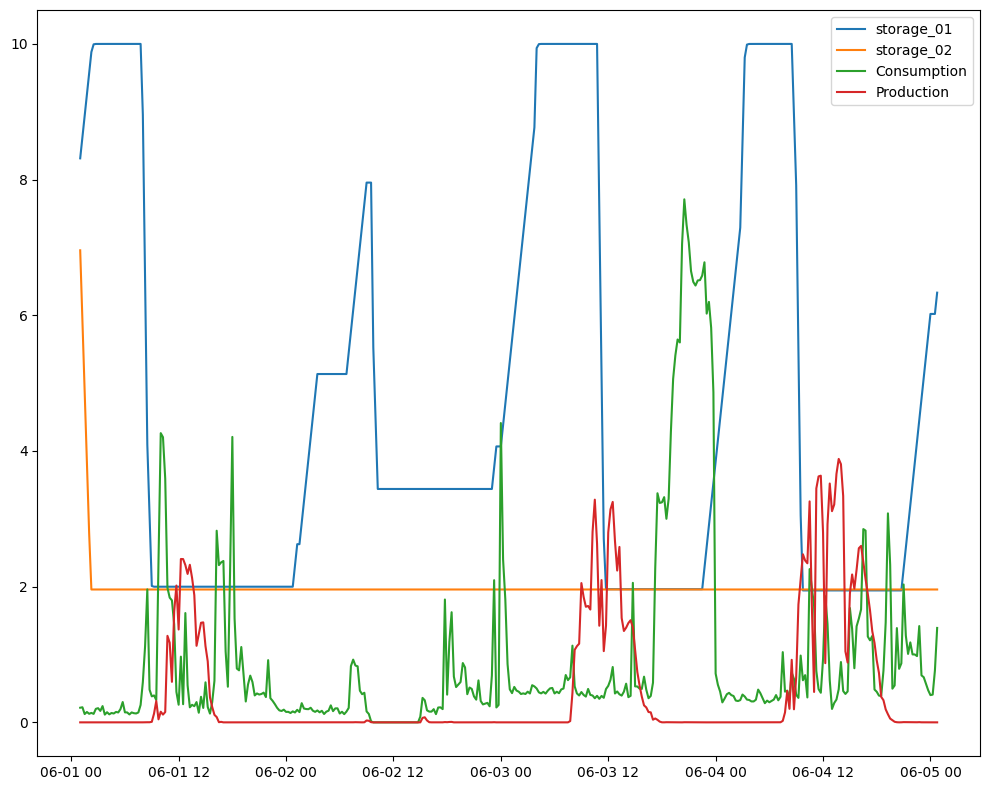

In [16]:
fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(10,8))

START = 0
END = 4

# Storage and EVs
for i in storages:
    axs.plot(pd_results.iloc[96*START:96*END].index, pd_results.iloc[96*START:96*END][i.name].values, label=i.name)

axs.plot(pd_results.iloc[96*START:96*END].index, test_env.load_consumption[96*START:96*END], label='Consumption')
axs.plot(pd_results.iloc[96*START:96*END].index, test_env.gen_production[96*START:96*END], label='Production')

axs.legend()

plt.tight_layout()
plt.show()